In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import sklearn as skl
import duckdb as ddb
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import prince        #%pip install prince
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"

In [2]:
df = pd.read_csv(r"C:\Users\valerio.fumasoli\Desktop\DISCRIMINANTE\ospedali.csv")

In [4]:
display(df)

,ID,Nominativo,Brand,Età,Sesso,Titolo_Studio,Professionalità_Medici,Competenza_Infermieristica,Efficacia_Cure,Comunicazione_Medici,Comfort_Stanze,Pulizia_Ambienti,Qualità_Cibo,Tempi_Attesa,Facilità_Prenotazione,Efficienza_Amministrativa,Soddisfazione_Globale,Disponibilità_Raccomandare
0,1,Lorenzo Lombardi,Policlinico Città Vecchia,35,M,Diploma,4,5,2,4,3,2,4,5,5,4,31.1,3.5
1,2,Nicola Conti,Policlinico Nord Italia,32,M,Licenza media,9,10,9,8,6,5,7,9,8,10,84.5,8.9
2,3,Alessandro Leone,Clinica Villa Aurora,51,M,Post-laurea,6,5,8,6,7,4,6,9,7,9,58.1,7.7
3,4,Riccardo Lombardi,Clinica Villa Serena,38,F,Post-laurea,8,9,9,7,8,7,6,9,7,8,78.5,6.9
4,5,Davide Colombo,Ospedale Santa Lucia,40,F,Diploma,7,8,6,6,6,7,5,7,7,7,52.8,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2195,2196,Nicola Moretti,Clinica Villa Serena,71,F,Diploma,6,6,6,5,9,9,10,5,6,5,73.6,6.2
2196,2197,Luca Costa,Policlinico Sant'Anna,52,M,Post-laurea,7,5,9,6,8,9,8,4,5,6,76.2,8.6
2197,2198,Roberta Marino,Policlinico Città Vecchia,49,F,Diploma,6,4,5,7,3,4,4,4,4,2,36.1,4.5
2198,2199,Elena Conti,Ospedale Regina Margherita,61,F,Post-laurea,6,6,9,6,10,9,9,7,6,10,71.7,6.0


In [5]:
df.rename(columns={'Brand':'Struttura'}, inplace=True)

In [6]:
df.columns

Index(['ID', 'Nominativo', 'Struttura', 'Età', 'Sesso', 'Titolo_Studio',
       'Professionalità_Medici', 'Competenza_Infermieristica',
       'Efficacia_Cure', 'Comunicazione_Medici', 'Comfort_Stanze',
       'Pulizia_Ambienti', 'Qualità_Cibo', 'Tempi_Attesa',
       'Facilità_Prenotazione', 'Efficienza_Amministrativa',
       'Soddisfazione_Globale', 'Disponibilità_Raccomandare'],
      dtype='str')

**EDA**

In [12]:
display(df.select_dtypes(include="number").describe(), df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          2200 non-null   int64  
 1   Nominativo                  2200 non-null   str    
 2   Struttura                   2200 non-null   str    
 3   Età                         2200 non-null   int64  
 4   Sesso                       2200 non-null   str    
 5   Titolo_Studio               2200 non-null   str    
 6   Professionalità_Medici      2200 non-null   int64  
 7   Competenza_Infermieristica  2200 non-null   int64  
 8   Efficacia_Cure              2200 non-null   int64  
 9   Comunicazione_Medici        2200 non-null   int64  
 10  Comfort_Stanze              2200 non-null   int64  
 11  Pulizia_Ambienti            2200 non-null   int64  
 12  Qualità_Cibo                2200 non-null   int64  
 13  Tempi_Attesa                2200 non-null   

,ID,Età,Professionalità_Medici,Competenza_Infermieristica,Efficacia_Cure,Comunicazione_Medici,Comfort_Stanze,Pulizia_Ambienti,Qualità_Cibo,Tempi_Attesa,Facilità_Prenotazione,Efficienza_Amministrativa,Soddisfazione_Globale,Disponibilità_Raccomandare
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,1100.500000,52.095000,6.530000,6.444545,6.559091,6.266364,6.111364,6.315455,5.798182,5.640000,5.922273,5.977727,61.448091,6.092682
std,635.229617,15.605603,2.221686,2.132410,2.315921,1.913775,2.251745,2.304974,1.962170,2.290705,2.137573,2.315292,14.941356,1.742082
min,1.000000,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,12.300000,0.400000
25%,550.750000,41.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.000000,4.000000,4.000000,4.000000,51.400000,4.900000
50%,1100.500000,52.000000,7.000000,6.000000,7.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,62.300000,6.100000
75%,1650.250000,62.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,7.000000,7.000000,7.000000,8.000000,72.325000,7.300000
max,2200.000000,92.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000,10.000000


None

*GROUPBY*

<Axes: xlabel='Struttura'>

Struttura                   Sesso
Clinica Villa Aurora        M        0.547059
                            F        0.452941
Clinica Villa Serena        F        0.537383
                            M        0.462617
Ospedale Regina Margherita  M        0.527094
                            F        0.472906
Ospedale San Bernardo       F        0.560606
                            M        0.439394
Ospedale San Giorgio        F        0.536232
                            M        0.463768
Ospedale Santa Chiara       F        0.581197
                            M        0.418803
Ospedale Santa Lucia        M        0.506173
                            F        0.493827
Policlinico Città Vecchia   F        0.525424
                            M        0.474576
Policlinico Nord Italia     F        0.534884
                            M        0.465116
Policlinico Sant'Anna       F        0.506329
                            M        0.493671
Name: proportion, dtype: float64

Struttura                   Sesso
Clinica Villa Aurora        M         93
                            F         77
Clinica Villa Serena        F        115
                            M         99
Ospedale Regina Margherita  M        107
                            F         96
Ospedale San Bernardo       F        111
                            M         87
Ospedale San Giorgio        F        111
                            M         96
Ospedale Santa Chiara       F        136
                            M         98
Ospedale Santa Lucia        M        123
                            F        120
Policlinico Città Vecchia   F        124
                            M        112
Policlinico Nord Italia     F        138
                            M        120
Policlinico Sant'Anna       F        120
                            M        117
Name: count, dtype: int64

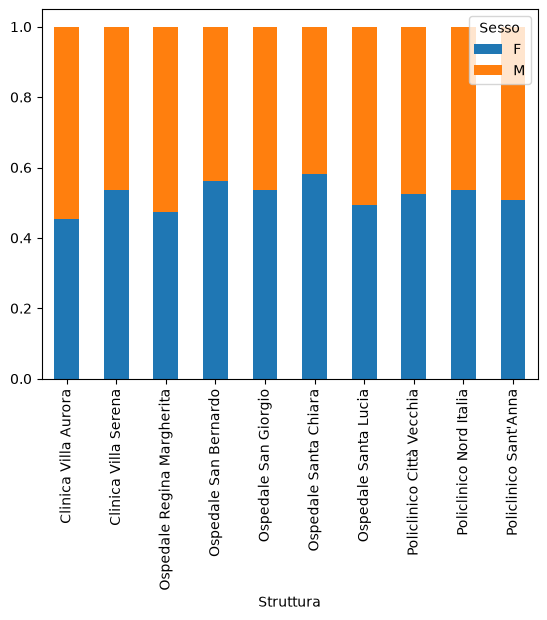

In [17]:
display(df.groupby('Struttura')['Sesso'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True))
display((df.groupby('Struttura')['Sesso'].value_counts(normalize=True)), df.groupby('Struttura')['Sesso'].value_counts())